In [1]:
!ls -lctr raw/msmarco

total 4
lrwxrwxrwx 1 leo leo 40 Feb 11 13:50 final_results_train.txt -> ../../../msmarco/final_results_train.txt
lrwxrwxrwx 1 leo leo 89 Feb 11 13:50 final_results_dev_official.txt -> ../../../../notebooks_2022/match_analysis/dev_offical_ours/final_results_dev_official.txt


In [10]:
!ls -lctr ../msmarco

total 1884
-rw-rw-r-- 1 leo leo   86461 Feb 11 13:50 test_distr.ipynb
-rw-rw-r-- 1 leo leo   17754 Feb 11 13:50 msmarco_matching.ipynb
-rw-rw-r-- 1 leo leo   11575 Mar  2 09:48 msmarco_matching.py
-rw-rw-r-- 1 leo leo 1804201 Mar 10 21:44 final_results_train.txt


In [11]:
import json
import os

from collections import defaultdict

def pos_to_bin(pos, step=256):
    return int(pos // step)

for part_src, part_name in [('train', 'msmarco_train'), ('dev_official', 'msmarco_dev')]:
    dt = json.load(open(f'raw/msmarco/final_results_{part_src}.txt'))
    
    doc_lens_dict = {str(e['docid']):pos_to_bin(e['document length (bert)']) for e in dt}
    match_start_dict = {}
    for e in dt:
        k = str(e['docid']), str(e['passid'])
        match_start_dict[k] = pos_to_bin(min(match_start_dict.get(k, float('inf')), e['match start (bert)'])) 
        
    dir_name = f'processed/{part_name}'
    os.makedirs(dir_name, exist_ok=True)
    with open(f'{dir_name}/doc_lens_dict.json', 'w') as out_f:
        json.dump(list(doc_lens_dict.items()), out_f)
    with open(f'{dir_name}/match_start_dict.json', 'w') as out_f:
        json.dump(list(match_start_dict.items()), out_f)        

(array([5338., 1197.,  525.,  236.,  104.,   87.,   55.,   34.,   55.]),
 array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]),
 <BarContainer object of 9 artists>)

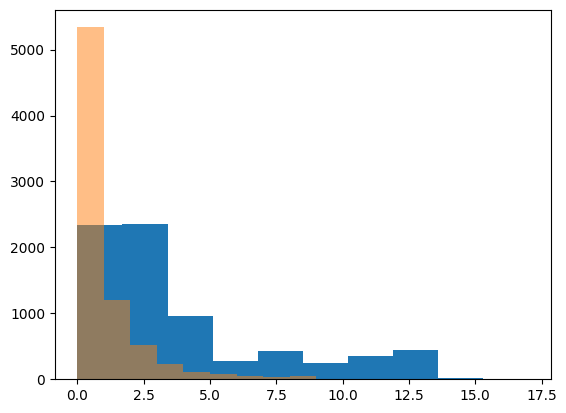

In [12]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
plt.hist(doc_lens_dict.values(), bins=10, alpha=1)
plt.hist(match_start_dict.values(), bins=np.arange(10), alpha=0.5)

In [4]:
#doc_lens_dict

In [5]:
#match_start_dict

In [6]:
!ls processed

gov2	     msmarco_train  test2019  test2021	web2014
msmarco_dev  robust04	    test2020  web2013


In [ ]:
#list(match_start_dict.items())